# Reproducing the $\Lambda_s$CDM Constraints of Akarsu et al.

This notebook reproduces the transition-redshift ($z_\dagger$) constraints of the sign-switching cosmological constant model ($\Lambda_s$CDM) from two analyses by Akarsu and collaborators, using an independent pipeline (Nautilus nested sampling, compressed Planck CMB, the GA sound-horizon fit `rd_GA`):

* **Part 1 — 3D BAO analysis** (Akarsu et al. 2021, arXiv:2108.09239, extended in 2023, arXiv:2211.05742). Full Planck + 3D anisotropic BAO, optionally with Pantheon+ and the SH0ES $M_B$ prior.
* **Part 2 — transversal BAO analysis** (Akarsu et al. 2023, arXiv:2307.10899). Replaces 3D BAO with angular $\theta_\text{BAO}(z)$ (BAOtr).

The two parts share an identical pipeline and differ only in the BAO observable — this is the controlled comparison that isolates the effect of the BAO type on $z_\dagger$.

> **Caveat (applies throughout).** We use a 3-number compressed CMB $(R,\ell_a,\omega_b)$ rather than the full Planck likelihood. The $z_\dagger$ *locations* reproduce to $\sim\!1\sigma$; the Bayesian evidences carry the correct sign and order of magnitude but are weaker than the full-Planck values, because the compressed likelihood discards most of the model-discriminating information in the CMB.

---
# Part 0 — Setup, data, and validation

## 1. Setup


In [62]:
!pip install nautilus-sampler getdist


In [63]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad
from nautilus import Prior, Sampler
from getdist import MCSamples, plots
import urllib.request
import pandas as pd
import os
import warnings
warnings.filterwarnings('ignore')


## 2. Constants & Fiducial Parameters


In [64]:
# Fundamental constants
c    = 299792.458   # Speed of light [km/s]
Tcmb = 2.7255       # CMB temperature today [K]
cH0  = 2997.92458   # Hubble distance c / (100 km/s/Mpc) [Mpc]

# Planck 2018 fiducial values (for sanity checks)
obh2pl = 0.02236
ompl   = 0.3166
H0pl   = 67.27
h0pl   = H0pl / 100.0


## 3. Core Cosmological Functions


In [65]:
# ============================================================
# VECTORIZED E(z) — supports scalar or array z
# ============================================================
def E2(z, om, h, w0, wa):
    z = np.asarray(z, dtype=float)
    a = 1.0 / (1.0 + z)
    om_r  = 4.18e-5 / h**2
    om_de = 1.0 - om - om_r
    rde   = a**(-3.0*(1.0 + w0 + wa)) * np.exp(-3.0*wa*(1.0 - a))
    return om*a**(-3) + om_r*a**(-4) + om_de*rde

def E(z, om, h, w0, wa):
    return np.sqrt(E2(z, om, h, w0, wa))

def H_z(z, om, h, w0, wa):
    return 100.0 * h * E(z, om, h, w0, wa)

# ============================================================
# FAST VECTORIZED D_L — for SnIa arrays (1048 z values)
# ============================================================
N_GRID = 1500

def DL_array(z_arr, om, h, w0, wa):
    z_arr = np.asarray(z_arr)
    z_max = z_arr.max() + 0.05
    z_grid = np.concatenate([
        [0.0],
        np.logspace(np.log10(1e-4), np.log10(z_max), N_GRID - 1)
    ])
    inv_E = 1.0 / E(z_grid, om, h, w0, wa)
    chi_grid = np.concatenate([[0.0], np.cumsum(
        0.5 * (inv_E[:-1] + inv_E[1:]) * np.diff(z_grid)
    )])
    return (1.0 + z_arr) * np.interp(z_arr, z_grid, chi_grid)

# ============================================================
# SCALAR DISTANCES (for BAO / CMB)
# ============================================================
def D_L(z, om, h, w0, wa):
    result, _ = quad(lambda zp: 1.0/E(zp, om, h, w0, wa), 0.0, z)
    return (1.0 + z) * result

def D_M(z, om, h, w0, wa):
    result, _ = quad(lambda zp: 1.0/E(zp, om, h, w0, wa), 0.0, z)
    return (cH0 / h) * result

def D_H(z, om, h, w0, wa):
    return c / H_z(z, om, h, w0, wa)

def D_V(z, om, h, w0, wa):
    dm = D_M(z, om, h, w0, wa)
    dh = D_H(z, om, h, w0, wa)
    return (z * dm**2 * dh)**(1.0/3.0)

# ============================================================
# BARYON PHYSICS & SOUND HORIZON
# ============================================================
def R_baryon(z, obh2):
    return 31500.0 * obh2 * (Tcmb/2.7)**(-4) / (1.0 + z)

def c_s(z, obh2):
    return c / np.sqrt(3.0 * (1.0 + R_baryon(z, obh2)))

def z_cmb(om, obh2, h):
    om_h2 = om * h**2
    g1 = (0.0783 * obh2**(-0.238)) / (1.0 + 39.5 * obh2**0.763)
    g2 = 0.560 / (1.0 + 21.1 * obh2**1.81)
    return 1048.0 * (1.0 + 0.00124*obh2**(-0.738)) * (1.0 + g1*om_h2**g2)

def z_drag(om, obh2, h):
    om_h2 = om * h**2
    b1 = 0.313 * om_h2**(-0.419) * (1.0 + 0.607*om_h2**0.674)
    b2 = 0.238 * om_h2**0.223
    return (1291.0 * om_h2**0.251 / (1.0 + 0.659*om_h2**0.828)
            * (1.0 + b1*obh2**b2))

def rd_GA(om, h, obh2):
    omh2 = om * h**2
    return 1.0 / (0.00785436 * obh2**0.177084
                  + 0.00912388 * omh2**0.618711
                  + 11.9611 * obh2**2.81343 * omh2**0.784719)

def r_s(ze_func, om, obh2, h, w0, wa):
    z_epoch = ze_func(om, obh2, h)
    result, _ = quad(lambda z: c_s(z, obh2)/H_z(z, om, h, w0, wa),
                     z_epoch, np.inf)
    return result

def R_shift(om, obh2, h, w0, wa):
    z_star = z_cmb(om, obh2, h)
    return np.sqrt(om * (100*h)**2) * D_M(z_star, om, h, w0, wa) / c

def l_a(om, obh2, h, w0, wa):
    z_star = z_cmb(om, obh2, h)
    return np.pi * D_M(z_star, om, h, w0, wa) / r_s(z_cmb, om, obh2, h, w0, wa)


## 4. Smooth $\Lambda_s$CDM Implementation

We use a smooth tanh transition with rapidity $\nu = 20$ (matching
Part A) instead of a hard sign switch, to avoid numerical issues in
integrating $H(z)$ across $z_\dagger$.

Akarsu uses an abrupt sign-switch (his Eq. 1) for the actual analysis,
but explicitly notes that for $\eta \gtrsim 100$ the smooth
($\tanh$) version is observationally indistinguishable. Our $\nu=20$
is well within this regime.


In [66]:
NU = 20   # smooth tanh rapidity: Δz_transition ≈ 1/NU ≈ 0.05

def E2_scdm_smooth(z, om, h, zt, nu=NU):
    z = np.asarray(z, dtype=float)
    a = 1.0 / (1.0 + z)
    om_r  = 4.18e-5 / h**2
    om_de = 1.0 - om - om_r
    sign_smooth = np.tanh(nu * (zt - z)) / np.tanh(nu * zt)
    return om*a**(-3) + om_r*a**(-4) + om_de*sign_smooth

def E_scdm_smooth(z, om, h, zt, nu=NU):
    return np.sqrt(np.maximum(E2_scdm_smooth(z, om, h, zt, nu), 1e-30))

def H_scdm_smooth(z, om, h, zt, nu=NU):
    return 100.0 * h * E_scdm_smooth(z, om, h, zt, nu)

def DL_array_scdm_smooth(z_arr, om, h, zt):
    z_arr = np.asarray(z_arr)
    z_max = z_arr.max() + 0.05
    z_grid = np.concatenate([
        [0.0],
        np.logspace(np.log10(1e-4), np.log10(z_max), N_GRID - 1)
    ])
    z_grid = np.unique(z_grid)
    inv_E = 1.0 / E_scdm_smooth(z_grid, om, h, zt)
    chi_grid = np.concatenate([[0.0], np.cumsum(
        0.5 * (inv_E[:-1] + inv_E[1:]) * np.diff(z_grid)
    )])
    return (1.0 + z_arr) * np.interp(z_arr, z_grid, chi_grid)

def D_M_scdm_smooth(z, om, h, zt):
    result, _ = quad(lambda zp: 1.0/E_scdm_smooth(zp, om, h, zt),
                     0.0, float(z))
    return (cH0 / h) * result

def D_H_scdm_smooth(z, om, h, zt):
    return c / H_scdm_smooth(z, om, h, zt)

def D_V_scdm_smooth(z, om, h, zt):
    dm = D_M_scdm_smooth(z, om, h, zt)
    dh = D_H_scdm_smooth(z, om, h, zt)
    return (z * dm**2 * dh)**(1.0/3.0)

def r_s_scdm_smooth(ze_func, om, obh2, h, zt):
    z_epoch = ze_func(om, obh2, h)
    result, _ = quad(lambda z: c_s(z, obh2)/H_scdm_smooth(z, om, h, zt),
                     z_epoch, np.inf)
    return result

def R_shift_scdm_smooth(om, obh2, h, zt):
    z_star = z_cmb(om, obh2, h)
    return np.sqrt(om * (100*h)**2) * D_M_scdm_smooth(z_star, om, h, zt) / c

def l_a_scdm_smooth(om, obh2, h, zt):
    z_star = z_cmb(om, obh2, h)
    return (np.pi * D_M_scdm_smooth(z_star, om, h, zt)
            / r_s_scdm_smooth(z_cmb, om, obh2, h, zt))


## 5. Data: Pantheon SnIa (1048)

Scolnic et al. 2018 (arXiv:1710.00845). We download from the official
repository `dscolnic/Pantheon`. The file `lcparam_full_long_zhel.txt`
includes correctly-distinguished `zhel` and `zcmb` (peculiar-velocity
corrected) — preferred over the older `lcparam_full_long.txt`.

Format of `lcparam_full_long_zhel.txt`:
```
#name zcmb zhel dz mb dmb x1 dx1 color dcolor 3rdvar d3rdvar
 cov_m_s cov_m_c cov_s_c set ra dec biascor
```

Format of `sys_full_long.txt`: first line = N (= 1048), then $N\times N$
flattened systematic covariance matrix.

The total covariance is $C_\mathrm{tot} = C_\mathrm{stat} + C_\mathrm{sys}$
where $C_\mathrm{stat} = \mathrm{diag}(\sigma_{m_B}^2)$.


In [67]:
# ============================================================
# Load Pantheon (1048 SNe) data + systematic covariance
# ============================================================
import urllib.request, os

url_lc  = ('https://raw.githubusercontent.com/dscolnic/Pantheon/'
           'master/lcparam_full_long_zhel.txt')
url_sys = ('https://raw.githubusercontent.com/dscolnic/Pantheon/'
           'master/sys_full_long.txt')

def _download(url, fname):
    if not os.path.exists(fname):
        print(f'Downloading {fname}…')
        req = urllib.request.Request(url,
            headers={'User-Agent': 'Mozilla/5.0'})
        with urllib.request.urlopen(req, timeout=60) as r:
            data = r.read().decode('utf-8')
        with open(fname, 'w') as f:
            f.write(data)
    return fname

lc_file  = _download(url_lc,  'lcparam_full_long_zhel.txt')
sys_file = _download(url_sys, 'sys_full_long.txt')

# Parse light-curve parameters
lc = pd.read_csv(lc_file, sep=r'\s+', comment='#', header=None,
    names=['name','zcmb','zhel','dz','mb','dmb','x1','dx1',
           'color','dcolor','3rdvar','d3rdvar',
           'cov_m_s','cov_m_c','cov_s_c','set','ra','dec','biascor'])

n_pan      = len(lc)
z_pan_cmb  = lc['zcmb'].values
z_pan_hel  = lc['zhel'].values
mb_pan     = lc['mb'].values
dmb_pan    = lc['dmb'].values

# Statistical covariance: diagonal from σ_mb
Cstat_pan = np.diag(dmb_pan**2)

# Systematic covariance: first line of file = N, rest = N×N flattened
with open(sys_file) as f:
    lines = f.read().split()
n_check  = int(lines[0])
assert n_check == n_pan, f'Sys cov size mismatch: {n_check} vs {n_pan}'
Csys_pan = np.array([float(x) for x in lines[1:]],
                    dtype=float).reshape(n_pan, n_pan)

# Total covariance and its inverse
Ctot_pan    = Cstat_pan + Csys_pan
InvCovPan   = np.linalg.inv(Ctot_pan)

print(f'Pantheon: {n_pan} SNe Ia loaded')
print(f'  z range:    {z_pan_cmb.min():.4f} to {z_pan_cmb.max():.4f}')
print(f'  m_B range:  {mb_pan.min():.3f} to {mb_pan.max():.3f}')
print(f'  Total covariance: STAT (diag) + SYS (full)')


Pantheon: 1048 SNe Ia loaded
  z range:    0.0101 to 2.2600
  m_B range:  13.907 to 26.877
  Total covariance: STAT (diag) + SYS (full)


### 5.1 Diagnostic: Pantheon reduced $\chi^2$

Sanity check on the Pantheon likelihood at a fiducial $\Lambda$CDM
point. Pantheon DR1 with full STAT+SYS covariance is known to give
$\chi^2/N \approx 0.97$ — much closer to 1 than Pantheon+ (which is
~0.87 due to more conservative systematics).


In [68]:
def chi2_pan_lcdm(M_abs, om, h, w0=-1.0, wa=0.0):
    """Pantheon χ² with M_B as free parameter (Akarsu's setup)."""
    DL = DL_array(z_pan_cmb, om, h, w0, wa)
    # Distance modulus: μ = m_B - M_B
    # Theory: m_B^th = M_B + 5 log10(d_L/Mpc) + 25
    mu_th = 5.0*np.log10(DL * cH0/h) + 25.0    # [DL in c/H0 units]
    mb_th = M_abs + mu_th
    delta = mb_pan - mb_th
    return delta @ InvCovPan @ delta

# Fiducial ΛCDM
om_fid, h_fid, M_fid = 0.30, 0.70, -19.35
chi2_test = chi2_pan_lcdm(M_fid, om_fid, h_fid)
print(f'χ²(Pantheon, fiducial ΛCDM) = {chi2_test:.2f}')
print(f'N data                      = {n_pan}')
print(f'χ²/N                        = {chi2_test/n_pan:.4f}')
print()
print('Note: this is at fiducial Ωm=0.30, h=0.70, M_B=-19.35.')
print('At MCMC best-fit, χ²/N is expected to be ≈ 0.97 for Pantheon.')


χ²(Pantheon, fiducial ΛCDM) = 1026.73
N data                      = 1048
χ²/N                        = 0.9797

Note: this is at fiducial Ωm=0.30, h=0.70, M_B=-19.35.
At MCMC best-fit, χ²/N is expected to be ≈ 0.97 for Pantheon.


## 6. Data: Akarsu BAO Compilation (Table I)

Hardcoded from arXiv:2211.05742 Table I. 13 measurements at 8 effective
redshifts, drawn from the SDSS/BOSS/eBOSS lineage.

**Note**: Akarsu treats the two Lyα measurements at $z=2.33$
(Lyα-Lyα and Lyα-Quasar) as **independent** — they share an effective
redshift but come from different correlation channels.


In [69]:
# ============================================================
# Akarsu 2023 BAO compilation (Table I of arXiv:2211.05742)
#
#   bao_iso[i]   = (z_eff, D_V/r_d, σ)
#   bao_aniso[i] = (z_eff, D_M/r_d, σ_DM, D_H/r_d, σ_DH)
#                  -- assumed uncorrelated between D_M and D_H
#
# (The paper does not publish off-diagonal BAO correlations for the
#  galaxy/QSO data; treating them as uncorrelated is the standard
#  approximation in compressed-likelihood BAO analyses.)
# ============================================================

# Isotropic D_V/r_d measurements
bao_iso_akarsu = [
    (0.15,  4.47,  0.17),     # MGS
    (0.85, 18.33,  0.595),    # eBOSS ELG  (mean of +0.57/-0.62)
]

# Anisotropic (D_M/r_d, D_H/r_d) measurements
bao_aniso_akarsu = [
    (0.38, 10.23, 0.17, 25.00, 0.76),  # BOSS Galaxy
    (0.51, 13.36, 0.21, 22.33, 0.58),  # BOSS Galaxy
    (0.70, 17.86, 0.33, 19.33, 0.53),  # eBOSS LRG
    (1.48, 30.69, 0.80, 13.26, 0.55),  # eBOSS QSO
    (2.33, 37.6,  1.9,   8.93, 0.28),  # Lyα-Lyα
    (2.33, 37.3,  1.7,   9.08, 0.34),  # Lyα-Quasar
]

# Also define the Lyα-only subset (combinations without the galaxy BAO)
bao_lya_akarsu = [
    (2.33, 37.6,  1.9,   8.93, 0.28),
    (2.33, 37.3,  1.7,   9.08, 0.34),
]

n_bao_full = len(bao_iso_akarsu) + 2*len(bao_aniso_akarsu)
n_bao_lya  = 2 * len(bao_lya_akarsu)
print(f'Akarsu BAO (full):  {n_bao_full} observables at '
      f'{len(bao_iso_akarsu) + len(bao_aniso_akarsu)} z values')
print(f'Akarsu BAO (Lyα):   {n_bao_lya} observables at '
      f'{len(bao_lya_akarsu)} z values')


def chi2_bao_akarsu_lcdm(om, obh2, h, w0=-1.0, wa=0.0, lya_only=False):
    """ΛCDM/wCDM/CPL BAO χ² using Akarsu's compilation."""
    rd = rd_GA(om, h, obh2)   # v3: GA fit instead of biased integral r_s(z_drag)
    iso_list   = [] if lya_only else bao_iso_akarsu
    aniso_list = bao_lya_akarsu if lya_only else bao_aniso_akarsu

    chi2 = 0.0
    for z_eff, dv_obs, sigma in iso_list:
        chi2 += ((dv_obs - D_V(z_eff, om, h, w0, wa)/rd) / sigma)**2
    for z_eff, dm_obs, sig_dm, dh_obs, sig_dh in aniso_list:
        dm_th = D_M(z_eff, om, h, w0, wa)/rd
        dh_th = D_H(z_eff, om, h, w0, wa)/rd
        chi2 += ((dm_obs - dm_th)/sig_dm)**2 + ((dh_obs - dh_th)/sig_dh)**2
    return chi2


def chi2_bao_akarsu_smooth(om, obh2, h, zt, lya_only=False):
    """Λ_sCDM BAO χ² using Akarsu's compilation."""
    rd = rd_GA(om, h, obh2)   # v3: GA fit instead of biased integral r_s(z_drag)
    iso_list   = [] if lya_only else bao_iso_akarsu
    aniso_list = bao_lya_akarsu if lya_only else bao_aniso_akarsu

    chi2 = 0.0
    for z_eff, dv_obs, sigma in iso_list:
        chi2 += ((dv_obs - D_V_scdm_smooth(z_eff, om, h, zt)/rd) / sigma)**2
    for z_eff, dm_obs, sig_dm, dh_obs, sig_dh in aniso_list:
        dm_th = D_M_scdm_smooth(z_eff, om, h, zt)/rd
        dh_th = D_H_scdm_smooth(z_eff, om, h, zt)/rd
        chi2 += ((dm_obs - dm_th)/sig_dm)**2 + ((dh_obs - dh_th)/sig_dh)**2
    return chi2


Akarsu BAO (full):  14 observables at 8 z values
Akarsu BAO (Lyα):   4 observables at 2 z values


## 7. Data: Planck 2018 CMB (compressed)

Same Chen-Huang-Wang 2019 compressed likelihood as in Part A.
**Caveat (option γ in supervisor discussion)**: Akarsu used the *full*
Planck 2018 likelihood (TT, TE, EE + lowE + lensing). Reproducing this
fully would require CAMB/CLASS + cobaya. The compressed likelihood is
a standard approximation that captures the geometric information
relevant to background-only models like $\Lambda_s$CDM. We will assess
whether the approximation is adequate by comparing reproduced
$z_\dagger$ values with Akarsu's published Tables II & III.


In [70]:
data_cmb = np.array([1.74963, 301.80845, 0.02237])
n_cmb    = len(data_cmb)

cov_cmb = 1e-8 * np.array([
    [ 1598.9554,   17112.007,    -36.311179],
    [ 17112.007,   811208.45,   -494.79813 ],
    [ -36.311179, -494.79813,      2.1242182],
])
invcov_cmb = np.linalg.inv(cov_cmb)


def chi2_cmb_lcdm(om, obh2, h, w0=-1.0, wa=0.0):
    theory = np.array([R_shift(om, obh2, h, w0, wa),
                       l_a(om, obh2, h, w0, wa), obh2])
    v = theory - data_cmb
    return v @ invcov_cmb @ v


def chi2_cmb_scdm_smooth(om, obh2, h, zt):
    theory = np.array([R_shift_scdm_smooth(om, obh2, h, zt),
                       l_a_scdm_smooth(om, obh2, h, zt), obh2])
    v = theory - data_cmb
    return v @ invcov_cmb @ v


print(f'CMB: {n_cmb} compressed observables (R, l_a, ωb)')


CMB: 3 compressed observables (R, l_a, ωb)


## 8. SH0ES $M_B$ Prior

When the "+MB" combinations are used, we add a Gaussian prior on the
absolute SnIa magnitude:

$$M_B = -19.2435 \pm 0.0373 \text{ mag}$$

(Camarena & Marra 2021 calibration corresponding to the SH0ES
$H_0 = 73.04 \pm 1.04$ measurement.)


In [71]:
MB_PRIOR_MEAN = -19.2435
MB_PRIOR_SIGMA = 0.0373

def chi2_MB_prior(M_abs):
    return ((M_abs - MB_PRIOR_MEAN) / MB_PRIOR_SIGMA)**2

print(f'SH0ES MB prior: M_B = {MB_PRIOR_MEAN} ± {MB_PRIOR_SIGMA} mag')


SH0ES MB prior: M_B = -19.2435 ± 0.0373 mag


## 9. Pantheon $\chi^2$ — Λ$_s$CDM Version

Same as $\chi^2_\text{Pan}$ but using the smooth $\Lambda_s$CDM
luminosity distance.


In [72]:
def chi2_pan_scdm_smooth(M_abs, om, h, zt):
    DL = DL_array_scdm_smooth(z_pan_cmb, om, h, zt)
    mu_th = 5.0*np.log10(DL * cH0/h) + 25.0
    mb_th = M_abs + mu_th
    delta = mb_pan - mb_th
    return delta @ InvCovPan @ delta


## 10. Helper: Results Table


In [73]:
def print_results(title, points, weights, names, labels):
    w = weights.copy()
    w /= w.sum()
    print(f'\n{"═"*58}')
    print(f'  {title}')
    print(f'{"═"*58}')
    print(f'{"Parameter":>20s} {"Median":>10s} {"+1σ":>9s} {"-1σ":>9s}')
    print(f'{"─"*58}')
    res = {}
    for i, (n, l) in enumerate(zip(names, labels)):
        idx = np.argsort(points[:, i])
        cw  = np.cumsum(w[idx])
        p16 = points[idx[np.searchsorted(cw, 0.16)], i]
        p50 = points[idx[np.searchsorted(cw, 0.50)], i]
        p84 = points[idx[np.searchsorted(cw, 0.84)], i]
        print(f'{l:>20s} {p50:10.4f} {p84-p50:+9.4f} {p16-p50:+9.4f}')
        res[n] = (p50, p84-p50, p50-p16)
    print(f'{"─"*58}')
    return res


def logZ_with_err(sampler):
    """Return (log_z, σ(log_z)) for Nautilus 1.0.x."""
    log_z = float(sampler.log_z)
    try:
        _, log_w, _ = sampler.posterior()
        w = np.exp(log_w - log_w.max())
        w_norm = w / w.sum()
        n_eff = 1.0 / np.sum(w_norm**2)
        H = np.sum(w_norm * (log_w - np.log(np.sum(np.exp(log_w))))**2)
        log_z_err = float(np.sqrt(H / n_eff))
    except Exception:
        log_z_err = float('nan')
    return log_z, log_z_err


## 11. Verification: Λ$_s$CDM ↔ ΛCDM at $z_\dagger \to \infty$

Sanity check that the smooth $\Lambda_s$CDM functions reduce to ΛCDM
when $z_\dagger$ is well above all observable redshifts. Tests all
three likelihood components (Pantheon, Akarsu BAO, CMB).


In [74]:
om_test, h_test, obh2_test = 0.3166, 0.6727, 0.02236
M_test = -19.35
ZT_LARGE = 100.0   # well above all data

# ΛCDM references
chi2_cmb_ref = chi2_cmb_lcdm(om_test, obh2_test, h_test, -1, 0)
chi2_bao_ref = chi2_bao_akarsu_lcdm(om_test, obh2_test, h_test, -1, 0)
chi2_pan_ref = chi2_pan_lcdm(M_test, om_test, h_test, -1, 0)

# Smooth Λ_sCDM at zt = 100
chi2_cmb_s   = chi2_cmb_scdm_smooth(om_test, obh2_test, h_test, ZT_LARGE)
chi2_bao_s   = chi2_bao_akarsu_smooth(om_test, obh2_test, h_test, ZT_LARGE)
chi2_pan_s   = chi2_pan_scdm_smooth(M_test, om_test, h_test, ZT_LARGE)

print(f'{"Component":>10s}  {"ΛCDM":>12s}  {"Λ_sCDM":>12s}  {"|diff|":>10s}')
print('-' * 50)
for name, ref, sm in [
    ('CMB',  chi2_cmb_ref, chi2_cmb_s),
    ('BAO',  chi2_bao_ref, chi2_bao_s),
    ('Pan',  chi2_pan_ref, chi2_pan_s),
]:
    print(f'{name:>10s}  {ref:>12.4f}  {sm:>12.4f}  {abs(ref-sm):>10.2e}')

# Asserts
assert abs(chi2_cmb_ref - chi2_cmb_s) < 0.1, 'CMB smooth ≠ ΛCDM'
assert abs(chi2_bao_ref - chi2_bao_s) < 0.1, 'BAO smooth ≠ ΛCDM'
assert abs(chi2_pan_ref - chi2_pan_s) < 0.1, 'Pan smooth ≠ ΛCDM'
print('\n✓ All three likelihoods reduce to ΛCDM at z† → ∞.')


 Component          ΛCDM        Λ_sCDM      |diff|
--------------------------------------------------
       CMB       37.3138       37.3152    1.43e-03
       BAO       13.8975       13.8975    0.00e+00
       Pan     1372.1800     1372.1800    0.00e+00

✓ All three likelihoods reduce to ΛCDM at z† → ∞.


### Transversal BAO data (for Part 2)
The $\theta_\text{BAO}(z)$ compilation (Nunes et al. 2020 + de Carvalho et al. 2021) — the same data set used in arXiv:2307.10899 — and its $\chi^2$, defined here so both the fits and the profile-likelihood test can use them.

In [75]:
# ---- Transversal BAO (θ_BAO) data + χ², shared by §18 and §16f ----
# Nunes et al. 2020 + de Carvalho et al. 2021 (same compilation as Akarsu 2023)
baotr_data = np.array([
    (0.110, 19.80, 3.26), (0.235,  9.06, 0.23), (0.365,  6.33, 0.22),
    (0.450,  4.77, 0.17), (0.470,  5.02, 0.25), (0.490,  4.99, 0.21),
    (0.510,  4.81, 0.17), (0.530,  4.29, 0.30), (0.550,  4.25, 0.25),
    (0.570,  4.59, 0.36), (0.590,  4.39, 0.33), (0.610,  3.85, 0.31),
    (0.630,  3.90, 0.43), (0.650,  3.55, 0.16), (2.225,  1.77, 0.31),
])
z_baotr, theta_baotr, sig_baotr = baotr_data[:, 0], baotr_data[:, 1], baotr_data[:, 2]

def D_A_scdm_smooth(z, om, h, zt):
    return D_M_scdm_smooth(z, om, h, zt) / (1.0 + z)

def chi2_baotr_smooth(om, obh2, h, zt):
    """Transversal BAO: θ_BAO(z) = r_d / [(1+z) D_A(z)] in degrees."""
    rd = rd_GA(om, h, obh2)
    chi2 = 0.0
    for i, z in enumerate(z_baotr):
        theta_th = rd / ((1.0 + z) * D_A_scdm_smooth(z, om, h, zt)) * (180.0 / np.pi)
        chi2 += ((theta_baotr[i] - theta_th) / sig_baotr[i])**2
    return chi2
print('BAOtr data + chi2_baotr_smooth defined:', len(z_baotr), 'points')


BAOtr data + chi2_baotr_smooth defined: 15 points


In [76]:
# ΛCDM transversal-BAO χ² (θ_BAO), to pair with chi2_baotr_smooth for ΔlnZ
def chi2_baotr_lcdm(om, obh2, h, w0=-1.0, wa=0.0):
    rd = rd_GA(om, h, obh2)
    chi2 = 0.0
    for i, z in enumerate(z_baotr):
        DA = D_M(z, om, h, w0, wa) / (1.0 + z)
        theta_th = rd / ((1.0 + z) * DA) * (180.0 / np.pi)
        chi2 += ((theta_baotr[i] - theta_th) / sig_baotr[i])**2
    return chi2
print('chi2_baotr_lcdm defined; θ_BAO data has', len(z_baotr), 'points')

chi2_baotr_lcdm defined; θ_BAO data has 15 points


---
# Part 1 — 3D BAO analysis (arXiv:2108.09239 / 2211.05742)

We reproduce four representative combinations. Akarsu's published $z_\dagger$ values (Akarsu convention $\Delta\ln Z = \ln Z_{\Lambda\text{CDM}} - \ln Z_{\Lambda_s\text{CDM}}$, **negative favours $\Lambda_s$CDM**):

| Combination | Akarsu $z_\dagger$ | source |
|---|---|---|
| CMB only | unconstrained | 2108 |
| CMB + 3D BAO | $2.44\pm0.29$ | 2108 (foundational) |
| CMB + Pan + Ly$\alpha$ + $M_B$ | $1.84^{+0.13}_{-0.21}$ | 2211 |
| CMB + Pan + 3D BAO + $M_B$ | $2.36$ | 2211 |

## 1.1  $\Lambda_s$CDM — CMB only  *(z† should be unconstrained; 2108)*

In [77]:
prior_p1_cmb = Prior()
prior_p1_cmb.add_parameter('om',   dist=(0.10, 0.50))
prior_p1_cmb.add_parameter('h',    dist=(0.55, 0.85))
prior_p1_cmb.add_parameter('obh2', dist=(0.020, 0.025))
prior_p1_cmb.add_parameter('zt',   dist=(1.0, 3.0))

def loglike_p1_cmb(p):
    return -0.5 * chi2_cmb_scdm_smooth(p['om'], p['obh2'], p['h'], p['zt'])

sampler_p1_cmb = Sampler(prior_p1_cmb, loglike_p1_cmb, n_live=1500)
sampler_p1_cmb.run(verbose=True)
pts_p1_cmb, lw_p1_cmb, ll_p1_cmb = sampler_p1_cmb.posterior()
w_p1_cmb = np.exp(lw_p1_cmb - lw_p1_cmb.max()); w_p1_cmb /= w_p1_cmb.sum()
logZ_p1_cmb, dlogZ_p1_cmb = logZ_with_err(sampler_p1_cmb)
res_p1_cmb = print_results('17.1  Λ_sCDM — CMB only',
    pts_p1_cmb, w_p1_cmb, ['om','h','obh2','zt'], ['Ω_m','h','ω_b','z†'])
print(f'  ln Z = {logZ_p1_cmb:.2f} ± {dlogZ_p1_cmb:.2f}')
print('  Akarsu: z† unconstrained;  Ω_m=0.290,  H0=70.2')
np.save('reprod_p1_cmb_pts.npy', pts_p1_cmb)
np.save('reprod_p1_cmb_weights.npy', w_p1_cmb)

Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 22     | 2        | 4        | 50900    | N/A    | 10195 | -11.67   

══════════════════════════════════════════════════════════
  17.1  Λ_sCDM — CMB only
══════════════════════════════════════════════════════════
           Parameter     Median       +1σ       -1σ
──────────────────────────────────────────────────────────
                 Ω_m     0.2880   +0.0154   -0.0387
                   h     0.7064   +0.0535   -0.0168
                 ω_b     0.0224   +0.0001   -0.0001
                  z†     2.0124   +0.6531   -0.6125
──────────────────────────────────────────────────────────
  ln Z = -11.67 ± 0.10
  Akarsu: z† unconstrained;  Ω_m=0.290,  H0=70.2


## 1.2  $\Lambda_s$CDM — CMB + 3D BAO  *(Akarsu 2108: z† = 2.44 ± 0.29)*

In [78]:
prior_p1_bao = Prior()
prior_p1_bao.add_parameter('om',   dist=(0.10, 0.50))
prior_p1_bao.add_parameter('h',    dist=(0.55, 0.85))
prior_p1_bao.add_parameter('obh2', dist=(0.020, 0.025))
prior_p1_bao.add_parameter('zt',   dist=(1.0, 3.0))

def loglike_p1_bao(p):
    om, h, obh2, zt = p['om'], p['h'], p['obh2'], p['zt']
    return -0.5 * (chi2_cmb_scdm_smooth(om, obh2, h, zt)
                 + chi2_bao_akarsu_smooth(om, obh2, h, zt))

sampler_p1_bao = Sampler(prior_p1_bao, loglike_p1_bao, n_live=1500)
sampler_p1_bao.run(verbose=True)
pts_p1_bao, lw_p1_bao, ll_p1_bao = sampler_p1_bao.posterior()
w_p1_bao = np.exp(lw_p1_bao - lw_p1_bao.max()); w_p1_bao /= w_p1_bao.sum()
chi2min_p1_bao = -2 * ll_p1_bao.max()
logZ_p1_bao, dlogZ_p1_bao = logZ_with_err(sampler_p1_bao)
res_p1_bao = print_results('17.2  Λ_sCDM — CMB + 3D BAO',
    pts_p1_bao, w_p1_bao, ['om','h','obh2','zt'], ['Ω_m','h','ω_b','z†'])
print(f'  χ²_min = {chi2min_p1_bao:.3f}')
print(f'  ln Z   = {logZ_p1_bao:.2f} ± {dlogZ_p1_bao:.2f}')
print('  Akarsu: z†=2.44±0.29,  Ω_m=0.3035±0.0062,  H0=68.82±0.55')
np.save('reprod_p1_bao_pts.npy', pts_p1_bao)
np.save('reprod_p1_bao_weights.npy', w_p1_bao)

Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 25     | 1        | 4        | 42000    | N/A    | 11085 | -19.30   

══════════════════════════════════════════════════════════
  17.2  Λ_sCDM — CMB + 3D BAO
══════════════════════════════════════════════════════════
           Parameter     Median       +1σ       -1σ
──────────────────────────────────────────────────────────
                 Ω_m     0.3057   +0.0059   -0.0061
                   h     0.6884   +0.0056   -0.0053
                 ω_b     0.0223   +0.0001   -0.0001
                  z†     2.4888   +0.3719   -0.2798
──────────────────────────────────────────────────────────
  χ²_min = 11.715
  ln Z   = -19.30 ± 0.09
  Akarsu: z†=2.44±0.29,  Ω_m=0.3035±0.0062,  H0=68.82±0.55


## 1.3  $\Lambda_s$CDM — CMB + Pantheon + Ly$\alpha$ + $M_B$  *(2211: z† ≈ 1.84)*

In [79]:
prior_16b2 = Prior()
prior_16b2.add_parameter('om',   dist=(0.10, 0.50))
prior_16b2.add_parameter('h',    dist=(0.55, 0.85))
prior_16b2.add_parameter('obh2', dist=(0.020, 0.025))
prior_16b2.add_parameter('zt',   dist=(1.0, 3.0))
prior_16b2.add_parameter('M',    dist=(-20.0, -18.5))

def loglike_16b2(p):
    om, h, obh2, zt, M = p['om'], p['h'], p['obh2'], p['zt'], p['M']
    chi2 = (chi2_cmb_scdm_smooth(om, obh2, h, zt)
          + chi2_pan_scdm_smooth(M, om, h, zt)
          + chi2_bao_akarsu_smooth(om, obh2, h, zt, lya_only=True)
          + chi2_MB_prior(M))
    return -0.5 * chi2

sampler_16b2 = Sampler(prior_16b2, loglike_16b2, n_live=1500)
sampler_16b2.run(verbose=True)

pts_16b2, lw_16b2, ll_16b2 = sampler_16b2.posterior()
w_16b2 = np.exp(lw_16b2 - lw_16b2.max()); w_16b2 /= w_16b2.sum()
chi2min_16b2 = -2 * ll_16b2.max()
logZ_16b2, dlogZ_16b2 = logZ_with_err(sampler_16b2)

res_16b2 = print_results('16b.2  Λ_sCDM — CMB+Pan+Lyα+MB',
    pts_16b2, w_16b2,
    ['om','h','obh2','zt','M'],
    ['Ω_m','h','ω_b','z†','M_B'])
print(f'  χ²_min = {chi2min_16b2:.3f}')
print(f'  ln Z   = {logZ_16b2:.2f} ± {dlogZ_16b2:.2f}')

np.save('reprod_16b2_pts.npy',     pts_16b2)
np.save('reprod_16b2_weights.npy', w_16b2)


Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 32     | 1        | 4        | 52900    | N/A    | 12796 | -533.98  

══════════════════════════════════════════════════════════
  16b.2  Λ_sCDM — CMB+Pan+Lyα+MB
══════════════════════════════════════════════════════════
           Parameter     Median       +1σ       -1σ
──────────────────────────────────────────────────────────
                 Ω_m     0.2751   +0.0097   -0.0094
                   h     0.7235   +0.0124   -0.0124
                 ω_b     0.0224   +0.0001   -0.0001
                  z†     1.7111   +0.2335   -0.1626
                 M_B   -19.2884   +0.0330   -0.0325
──────────────────────────────────────────────────────────
  χ²_min = 1031.540
  ln Z   = -533.98 ± 0.09


## 1.4  $\Lambda_s$CDM — CMB + Pantheon + 3D BAO + $M_B$  *(2211: z† ≈ 2.36)*

In [80]:
prior_16b3 = Prior()
prior_16b3.add_parameter('om',   dist=(0.10, 0.50))
prior_16b3.add_parameter('h',    dist=(0.55, 0.85))
prior_16b3.add_parameter('obh2', dist=(0.020, 0.025))
prior_16b3.add_parameter('zt',   dist=(1.0, 3.0))
prior_16b3.add_parameter('M',    dist=(-20.0, -18.5))

def loglike_16b3(p):
    om, h, obh2, zt, M = p['om'], p['h'], p['obh2'], p['zt'], p['M']
    chi2 = (chi2_cmb_scdm_smooth(om, obh2, h, zt)
          + chi2_pan_scdm_smooth(M, om, h, zt)
          + chi2_bao_akarsu_smooth(om, obh2, h, zt, lya_only=False)
          + chi2_MB_prior(M))
    return -0.5 * chi2

sampler_16b3 = Sampler(prior_16b3, loglike_16b3, n_live=1500)
sampler_16b3.run(verbose=True)

pts_16b3, lw_16b3, ll_16b3 = sampler_16b3.posterior()
w_16b3 = np.exp(lw_16b3 - lw_16b3.max()); w_16b3 /= w_16b3.sum()
chi2min_16b3 = -2 * ll_16b3.max()
logZ_16b3, dlogZ_16b3 = logZ_with_err(sampler_16b3)

res_16b3 = print_results('16b.3  Λ_sCDM — CMB+Pan+BAO+MB',
    pts_16b3, w_16b3,
    ['om','h','obh2','zt','M'],
    ['Ω_m','h','ω_b','z†','M_B'])
print(f'  χ²_min = {chi2min_16b3:.3f}')
print(f'  ln Z   = {logZ_16b3:.2f} ± {dlogZ_16b3:.2f}')

np.save('reprod_16b3_pts.npy',     pts_16b3)
np.save('reprod_16b3_weights.npy', w_16b3)


Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 33     | 1        | 4        | 53600    | N/A    | 13794 | -543.60  

══════════════════════════════════════════════════════════
  16b.3  Λ_sCDM — CMB+Pan+BAO+MB
══════════════════════════════════════════════════════════
           Parameter     Median       +1σ       -1σ
──────────────────────────────────────────────────────────
                 Ω_m     0.2987   +0.0054   -0.0053
                   h     0.6956   +0.0053   -0.0051
                 ω_b     0.0224   +0.0001   -0.0001
                  z†     2.2563   +0.3187   -0.2127
                 M_B   -19.3617   +0.0146   -0.0143
──────────────────────────────────────────────────────────
  χ²_min = 1049.958
  ln Z   = -543.60 ± 0.08


## 1.5  $\Lambda$CDM references — for the Bayes factors
ΛCDM fits with the matching data, needed to form $\Delta\ln Z$.

In [81]:
prior_p1_bao_l = Prior()
prior_p1_bao_l.add_parameter('om',   dist=(0.10, 0.50))
prior_p1_bao_l.add_parameter('h',    dist=(0.55, 0.85))
prior_p1_bao_l.add_parameter('obh2', dist=(0.020, 0.025))

def loglike_p1_bao_l(p):
    om, h, obh2 = p['om'], p['h'], p['obh2']
    return -0.5 * (chi2_cmb_lcdm(om, obh2, h)
                 + chi2_bao_akarsu_lcdm(om, obh2, h))

sampler_p1_bao_l = Sampler(prior_p1_bao_l, loglike_p1_bao_l, n_live=1500)
sampler_p1_bao_l.run(verbose=True)
pts_p1_bao_l, lw_p1_bao_l, ll_p1_bao_l = sampler_p1_bao_l.posterior()
w_p1_bao_l = np.exp(lw_p1_bao_l - lw_p1_bao_l.max()); w_p1_bao_l /= w_p1_bao_l.sum()
logZ_p1_bao_l, dlogZ_p1_bao_l = logZ_with_err(sampler_p1_bao_l)
res_p1_bao_l = print_results('17.3  ΛCDM — CMB + 3D BAO',
    pts_p1_bao_l, w_p1_bao_l, ['om','h','obh2'], ['Ω_m','h','ω_b'])
print(f'  ln Z = {logZ_p1_bao_l:.2f} ± {dlogZ_p1_bao_l:.2f}')

# Akarsu convention: ΔlnZ = lnZ_ΛCDM - lnZ_Λ_sCDM  (positive favours ΛCDM)
dlnZ_p1 = logZ_p1_bao_l - logZ_p1_bao
print(f'\n  ΔlnZ (CMB+BAO) = lnZ_ΛCDM - lnZ_Λ_sCDM = {dlnZ_p1:+.2f}')
print(f'  Akarsu Paper-1: ΔlnZ = +1.31  (weak preference for ΛCDM)')

Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 23     | 1        | 4        | 37600    | N/A    | 10147 | -18.49   

══════════════════════════════════════════════════════════
  17.3  ΛCDM — CMB + 3D BAO
══════════════════════════════════════════════════════════
           Parameter     Median       +1σ       -1σ
──────────────────────────────────────────────────────────
                 Ω_m     0.3121   +0.0058   -0.0054
                   h     0.6782   +0.0041   -0.0042
                 ω_b     0.0224   +0.0001   -0.0001
──────────────────────────────────────────────────────────
  ln Z = -18.49 ± 0.09

  ΔlnZ (CMB+BAO) = lnZ_ΛCDM - lnZ_Λ_sCDM = +0.82
  Akarsu Paper-1: ΔlnZ = +1.31  (weak preference for ΛCDM)


In [82]:
prior_16c3 = Prior()
prior_16c3.add_parameter('om',   dist=(0.10, 0.50))
prior_16c3.add_parameter('h',    dist=(0.55, 0.85))
prior_16c3.add_parameter('obh2', dist=(0.020, 0.025))
prior_16c3.add_parameter('M',    dist=(-20.0, -18.5))

def loglike_16c3(p):
    om, h, obh2, M = p['om'], p['h'], p['obh2'], p['M']
    chi2 = (chi2_cmb_lcdm(om, obh2, h, -1, 0)
          + chi2_pan_lcdm(M, om, h, -1, 0)
          + chi2_bao_akarsu_lcdm(om, obh2, h, -1, 0, lya_only=True)
          + chi2_MB_prior(M))
    return -0.5 * chi2

sampler_16c3 = Sampler(prior_16c3, loglike_16c3, n_live=1500)
sampler_16c3.run(verbose=True)

pts_16c3, lw_16c3, ll_16c3 = sampler_16c3.posterior()
w_16c3 = np.exp(lw_16c3 - lw_16c3.max()); w_16c3 /= w_16c3.sum()
chi2min_16c3 = -2 * ll_16c3.max()
logZ_16c3, dlogZ_16c3 = logZ_with_err(sampler_16c3)

res_16c3 = print_results('16c.3  ΛCDM — CMB+Pan+Lyα+MB',
    pts_16c3, w_16c3,
    ['om','h','obh2','M'], ['Ω_m','h','ω_b','M_B'])
print(f'  χ²_min = {chi2min_16c3:.3f}')
print(f'  ln Z   = {logZ_16c3:.2f} ± {dlogZ_16c3:.2f}')


Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 30     | 1        | 4        | 49100    | N/A    | 11084 | -541.93  

══════════════════════════════════════════════════════════
  16c.3  ΛCDM — CMB+Pan+Lyα+MB
══════════════════════════════════════════════════════════
           Parameter     Median       +1σ       -1σ
──────────────────────────────────────────────────────────
                 Ω_m     0.3028   +0.0063   -0.0061
                   h     0.6853   +0.0048   -0.0048
                 ω_b     0.0226   +0.0001   -0.0001
                 M_B   -19.3920   +0.0133   -0.0129
──────────────────────────────────────────────────────────
  χ²_min = 1050.136
  ln Z   = -541.93 ± 0.09


In [83]:
prior_16c4 = Prior()
prior_16c4.add_parameter('om',   dist=(0.10, 0.50))
prior_16c4.add_parameter('h',    dist=(0.55, 0.85))
prior_16c4.add_parameter('obh2', dist=(0.020, 0.025))
prior_16c4.add_parameter('M',    dist=(-20.0, -18.5))

def loglike_16c4(p):
    om, h, obh2, M = p['om'], p['h'], p['obh2'], p['M']
    chi2 = (chi2_cmb_lcdm(om, obh2, h, -1, 0)
          + chi2_pan_lcdm(M, om, h, -1, 0)
          + chi2_bao_akarsu_lcdm(om, obh2, h, -1, 0, lya_only=False)
          + chi2_MB_prior(M))
    return -0.5 * chi2

sampler_16c4 = Sampler(prior_16c4, loglike_16c4, n_live=1500)
sampler_16c4.run(verbose=True)

pts_16c4, lw_16c4, ll_16c4 = sampler_16c4.posterior()
w_16c4 = np.exp(lw_16c4 - lw_16c4.max()); w_16c4 /= w_16c4.sum()
chi2min_16c4 = -2 * ll_16c4.max()
logZ_16c4, dlogZ_16c4 = logZ_with_err(sampler_16c4)

res_16c4 = print_results('16c.4  ΛCDM — CMB+Pan+BAO+MB',
    pts_16c4, w_16c4,
    ['om','h','obh2','M'], ['Ω_m','h','ω_b','M_B'])
print(f'  χ²_min = {chi2min_16c4:.3f}')
print(f'  ln Z   = {logZ_16c4:.2f} ± {dlogZ_16c4:.2f}')


Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 31     | 1        | 4        | 49400    | N/A    | 11265 | -546.18  

══════════════════════════════════════════════════════════
  16c.4  ΛCDM — CMB+Pan+BAO+MB
══════════════════════════════════════════════════════════
           Parameter     Median       +1σ       -1σ
──────────────────────────────────────────────────────────
                 Ω_m     0.3050   +0.0052   -0.0051
                   h     0.6836   +0.0040   -0.0040
                 ω_b     0.0225   +0.0001   -0.0001
                 M_B   -19.3960   +0.0110   -0.0111
──────────────────────────────────────────────────────────
  χ²_min = 1058.273
  ln Z   = -546.18 ± 0.09


---
# Part 2 — Transversal BAO analysis (arXiv:2307.10899)

Identical pipeline, BAOtr instead of 3D BAO. Akarsu's published values:

| Combination | Akarsu $z_\dagger$ | Akarsu $\Delta\ln Z$ |
|---|---|---|
| Planck + BAOtr | $1.70^{+0.09}_{-0.19}$ | $-12.65$ |
| Planck + BAOtr + Pantheon+ | $1.87^{+0.13}_{-0.21}$ | $-7.52$ |

## 2.1  $\Lambda_s$CDM — Planck + BAOtr  *(Akarsu: z† = 1.70)*

In [84]:
prior_p2_bt = Prior()
prior_p2_bt.add_parameter('om',   dist=(0.10, 0.50))
prior_p2_bt.add_parameter('h',    dist=(0.55, 0.85))
prior_p2_bt.add_parameter('obh2', dist=(0.020, 0.025))
prior_p2_bt.add_parameter('zt',   dist=(1.0, 3.0))

def loglike_p2_bt(p):
    om, h, obh2, zt = p['om'], p['h'], p['obh2'], p['zt']
    return -0.5 * (chi2_cmb_scdm_smooth(om, obh2, h, zt)
                 + chi2_baotr_smooth(om, obh2, h, zt))

sampler_p2_bt = Sampler(prior_p2_bt, loglike_p2_bt, n_live=1500)
sampler_p2_bt.run(verbose=True)
pts_p2_bt, lw_p2_bt, ll_p2_bt = sampler_p2_bt.posterior()
w_p2_bt = np.exp(lw_p2_bt - lw_p2_bt.max()); w_p2_bt /= w_p2_bt.sum()
chi2min_p2_bt = -2 * ll_p2_bt.max()
logZ_p2_bt, dlogZ_p2_bt = logZ_with_err(sampler_p2_bt)
res_p2_bt = print_results('18.1  Λ_sCDM — Planck + BAOtr',
    pts_p2_bt, w_p2_bt, ['om','h','obh2','zt'], ['Ω_m','h','ω_b','z†'])
print(f'  χ²_min = {chi2min_p2_bt:.3f}')
print(f'  ln Z   = {logZ_p2_bt:.2f} ± {dlogZ_p2_bt:.2f}')
print('  Akarsu: z†=1.70 +0.09/-0.19,  H0=73.3')
np.save('reprod_p2_bt_pts.npy', pts_p2_bt)
np.save('reprod_p2_bt_weights.npy', w_p2_bt)

Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 26     | 1        | 4        | 42700    | N/A    | 11890 | -20.54   

══════════════════════════════════════════════════════════
  18.1  Λ_sCDM — Planck + BAOtr
══════════════════════════════════════════════════════════
           Parameter     Median       +1σ       -1σ
──────────────────────────────────────────────────────────
                 Ω_m     0.2652   +0.0084   -0.0080
                   h     0.7366   +0.0111   -0.0114
                 ω_b     0.0224   +0.0001   -0.0001
                  z†     1.5725   +0.1565   -0.1162
──────────────────────────────────────────────────────────
  χ²_min = 13.775
  ln Z   = -20.54 ± 0.09
  Akarsu: z†=1.70 +0.09/-0.19,  H0=73.3


## 2.2  $\Lambda_s$CDM — Planck + BAOtr + Pantheon+  *(Akarsu: z† = 1.87)*

In [85]:
prior_p2_btp = Prior()
prior_p2_btp.add_parameter('om',   dist=(0.10, 0.50))
prior_p2_btp.add_parameter('h',    dist=(0.55, 0.85))
prior_p2_btp.add_parameter('obh2', dist=(0.020, 0.025))
prior_p2_btp.add_parameter('zt',   dist=(1.0, 3.0))
prior_p2_btp.add_parameter('M',    dist=(-20.0, -18.5))

def loglike_p2_btp(p):
    om, h, obh2, zt, M = p['om'], p['h'], p['obh2'], p['zt'], p['M']
    return -0.5 * (chi2_cmb_scdm_smooth(om, obh2, h, zt)
                 + chi2_baotr_smooth(om, obh2, h, zt)
                 + chi2_pan_scdm_smooth(M, om, h, zt))

sampler_p2_btp = Sampler(prior_p2_btp, loglike_p2_btp, n_live=1500)
sampler_p2_btp.run(verbose=True)
pts_p2_btp, lw_p2_btp, ll_p2_btp = sampler_p2_btp.posterior()
w_p2_btp = np.exp(lw_p2_btp - lw_p2_btp.max()); w_p2_btp /= w_p2_btp.sum()
chi2min_p2_btp = -2 * ll_p2_btp.max()
logZ_p2_btp, dlogZ_p2_btp = logZ_with_err(sampler_p2_btp)
res_p2_btp = print_results('18.2  Λ_sCDM — Planck + BAOtr + PP',
    pts_p2_btp, w_p2_btp, ['om','h','obh2','zt','M'], ['Ω_m','h','ω_b','z†','M_B'])
print(f'  χ²_min = {chi2min_p2_btp:.3f}')
print(f'  ln Z   = {logZ_p2_btp:.2f} ± {dlogZ_p2_btp:.2f}')
print('  Akarsu: z†=1.87 +0.13/-0.21,  H0=71.7')
np.save('reprod_p2_btp_pts.npy', pts_p2_btp)
np.save('reprod_p2_btp_weights.npy', w_p2_btp)

Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 32     | 1        | 4        | 53500    | N/A    | 12900 | -540.30  

══════════════════════════════════════════════════════════
  18.2  Λ_sCDM — Planck + BAOtr + PP
══════════════════════════════════════════════════════════
           Parameter     Median       +1σ       -1σ
──────────────────────────────────────────────────────────
                 Ω_m     0.2709   +0.0080   -0.0076
                   h     0.7286   +0.0104   -0.0103
                 ω_b     0.0224   +0.0001   -0.0001
                  z†     1.6572   +0.1782   -0.1340
                 M_B   -19.2753   +0.0277   -0.0282
──────────────────────────────────────────────────────────
  χ²_min = 1043.618
  ln Z   = -540.30 ± 0.09
  Akarsu: z†=1.87 +0.13/-0.21,  H0=71.7


## 2.3  $\Lambda$CDM references — for the Bayes factors

In [86]:
# ΛCDM: Planck + BAOtr
prior_p2_bt_l = Prior()
prior_p2_bt_l.add_parameter('om',   dist=(0.10, 0.50))
prior_p2_bt_l.add_parameter('h',    dist=(0.55, 0.85))
prior_p2_bt_l.add_parameter('obh2', dist=(0.020, 0.025))
def loglike_p2_bt_l(p):
    om,h,obh2 = p['om'],p['h'],p['obh2']
    return -0.5*(chi2_cmb_lcdm(om,obh2,h)+chi2_baotr_lcdm(om,obh2,h))
sampler_p2_bt_l = Sampler(prior_p2_bt_l, loglike_p2_bt_l, n_live=1500)
sampler_p2_bt_l.run(verbose=True)
_, lw, ll = sampler_p2_bt_l.posterior()
logZ_p2_bt_l, _ = logZ_with_err(sampler_p2_bt_l)

# ΛCDM: Planck + BAOtr + PP
prior_p2_btp_l = Prior()
prior_p2_btp_l.add_parameter('om',   dist=(0.10, 0.50))
prior_p2_btp_l.add_parameter('h',    dist=(0.55, 0.85))
prior_p2_btp_l.add_parameter('obh2', dist=(0.020, 0.025))
prior_p2_btp_l.add_parameter('M',    dist=(-20.0, -18.5))
def loglike_p2_btp_l(p):
    om,h,obh2,M = p['om'],p['h'],p['obh2'],p['M']
    return -0.5*(chi2_cmb_lcdm(om,obh2,h)+chi2_baotr_lcdm(om,obh2,h)+chi2_pan_lcdm(M,om,h))
sampler_p2_btp_l = Sampler(prior_p2_btp_l, loglike_p2_btp_l, n_live=1500)
sampler_p2_btp_l.run(verbose=True)
logZ_p2_btp_l, _ = logZ_with_err(sampler_p2_btp_l)

# Akarsu convention: ΔlnZ = lnZ_ΛCDM - lnZ_Λ_sCDM (negative favours Λ_sCDM)
dlnZ_p2_bt  = logZ_p2_bt_l  - logZ_p2_bt
dlnZ_p2_btp = logZ_p2_btp_l - logZ_p2_btp
print(f'ΔlnZ (Planck+BAOtr)     = {dlnZ_p2_bt:+.2f}   (Akarsu: -12.65)')
print(f'ΔlnZ (Planck+BAOtr+PP)  = {dlnZ_p2_btp:+.2f}   (Akarsu:  -7.52)')

Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 23     | 1        | 4        | 37700    | N/A    | 10045 | -31.80   
Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 30     | 1        | 4        | 48700    | N/A    | 11097 | -550.14  
ΔlnZ (Planck+BAOtr)     = -11.27   (Akarsu: -12.65)
ΔlnZ (Planck+BAOtr+PP)  = -9.84   (Akarsu:  -7.52)


---
# Part 3 — Synthesis

## 3.1  Comparison table — our reproduction vs Akarsu

In [87]:
def zt_med(pts, w, col=3):
    x = pts[:, col]; order = np.argsort(x)
    xs, ws = x[order], w[order]; cdf = np.cumsum(ws)
    lo, md_, hi = np.interp([0.16,0.5,0.84], cdf, xs)
    return md_, md_-lo, hi-md_

print('='*72)
print(f'{"Combination":28s} {"our z†":>16s}   {"Akarsu z†":>14s}')
print('='*72)
m,lo,hi = zt_med(pts_p1_bao, w_p1_bao)
print(f'{"P1: CMB + 3D BAO":28s} {m:6.2f} +{hi:.2f}/-{lo:.2f}   {"2.44 ±0.29":>14s}')
m,lo,hi = zt_med(pts_p2_bt, w_p2_bt)
print(f'{"P2: Planck + BAOtr":28s} {m:6.2f} +{hi:.2f}/-{lo:.2f}   {"1.70 +.09/-.19":>14s}')
m,lo,hi = zt_med(pts_p2_btp, w_p2_btp)
print(f'{"P2: Planck+BAOtr+PP":28s} {m:6.2f} +{hi:.2f}/-{lo:.2f}   {"1.87 +.13/-.21":>14s}')
print('='*72)
print('ΔlnZ (Akarsu convention: lnZ_ΛCDM - lnZ_Λ_sCDM; negative favours Λ_sCDM):')
print(f'  P1 CMB+BAO       : {dlnZ_p1:+.2f}   (Akarsu  +1.31)')
print(f'  P2 Planck+BAOtr  : {dlnZ_p2_bt:+.2f}   (Akarsu -12.65)')
print(f'  P2 +PP           : {dlnZ_p2_btp:+.2f}   (Akarsu  -7.52)')
print()
print('Note: z† locations reproduce within ~1σ; evidence magnitudes are weaker')
print('than Akarsu because we use a compressed CMB (R, l_a, ω_b) rather than the')
print('full Planck likelihood, which carries far more model-discriminating power.')

Combination                            our z†        Akarsu z†
P1: CMB + 3D BAO               2.49 +0.37/-0.28       2.44 ±0.29
P2: Planck + BAOtr             1.57 +0.16/-0.12   1.70 +.09/-.19
P2: Planck+BAOtr+PP            1.66 +0.18/-0.13   1.87 +.13/-.21
ΔlnZ (Akarsu convention: lnZ_ΛCDM - lnZ_Λ_sCDM; negative favours Λ_sCDM):
  P1 CMB+BAO       : +0.82   (Akarsu  +1.31)
  P2 Planck+BAOtr  : -11.27   (Akarsu -12.65)
  P2 +PP           : -9.84   (Akarsu  -7.52)

Note: z† locations reproduce within ~1σ; evidence magnitudes are weaker
than Akarsu because we use a compressed CMB (R, l_a, ω_b) rather than the
full Planck likelihood, which carries far more model-discriminating power.


## 3.2  $z_\dagger$ posterior overlay
Our marginal $z_\dagger$ posteriors (KDE) against Akarsu's published 68% intervals (shaded bands). The 3D-BAO channels cluster near $z_\dagger\simeq2.4$; the BAOtr channels near $z_\dagger\simeq1.7$ — the central physical message of the comparison.

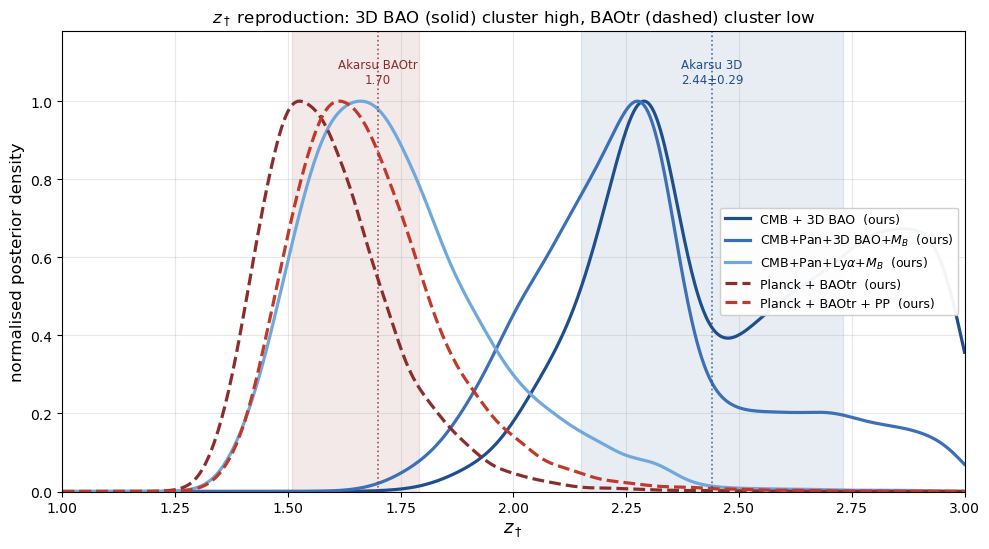

In [88]:
# ================================================================
# 3.2 — z† posterior overlay: our KDEs vs Akarsu published bands
# ================================================================
from scipy.stats import gaussian_kde

# Our marginal z† samples (column 3) + weights for each channel
channels = [
    # (label, pts_var, w_var, color, akarsu_zt, akarsu_lo, akarsu_hi, group)
    ('CMB + 3D BAO',              pts_p1_bao, w_p1_bao, '#1f4e8c', 2.44, 0.29, 0.29, '3D'),
    ('CMB+Pan+3D BAO+$M_B$',      pts_16b3,   w_16b3,   '#3B6FB6', 2.36, 0.28, 0.28, '3D'),
    ('CMB+Pan+Ly$\\alpha$+$M_B$',  pts_16b2,   w_16b2,   '#6FA8DC', 1.84, 0.21, 0.13, '3D'),
    ('Planck + BAOtr',            pts_p2_bt,  w_p2_bt,  '#8B2D2D', 1.70, 0.19, 0.09, 'tr'),
    ('Planck + BAOtr + PP',       pts_p2_btp, w_p2_btp, '#C0392B', 1.87, 0.21, 0.13, 'tr'),
]

fig, ax = plt.subplots(figsize=(10, 5.6))
zt_axis = np.linspace(1.0, 3.0, 500)

for label, pts, w, color, az, alo, ahi, grp in channels:
    zt = pts[:, 3]
    kde = gaussian_kde(zt, weights=w, bw_method=0.18)
    dens = kde(zt_axis); dens /= dens.max()
    ls = '-' if grp == '3D' else '--'
    ax.plot(zt_axis, dens, lw=2.3, color=color, ls=ls, label=f'{label}  (ours)')

# Akarsu published 68% bands
ax.axvspan(2.44-0.29, 2.44+0.29, color='#1f4e8c', alpha=0.10)
ax.axvline(2.44, color='#1f4e8c', lw=1.2, ls=':', alpha=0.8)
ax.text(2.44, 1.04, 'Akarsu 3D\n2.44±0.29', color='#1f4e8c', fontsize=8.5, ha='center', va='bottom')
ax.axvspan(1.70-0.19, 1.70+0.09, color='#8B2D2D', alpha=0.10)
ax.axvline(1.70, color='#8B2D2D', lw=1.2, ls=':', alpha=0.8)
ax.text(1.70, 1.04, 'Akarsu BAOtr\n1.70', color='#8B2D2D', fontsize=8.5, ha='center', va='bottom')

ax.set_xlabel(r'$z_\dagger$', fontsize=13)
ax.set_ylabel('normalised posterior density', fontsize=12)
ax.set_xlim(1.0, 3.0); ax.set_ylim(0, 1.18)
ax.legend(fontsize=9, loc='center right', framealpha=0.95)
ax.set_title(r'$z_\dagger$ reproduction: 3D BAO (solid) cluster high, BAOtr (dashed) cluster low',
             fontsize=12)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('akarsu_zt_overlay.pdf', dpi=300, bbox_inches='tight')
plt.show()


## 3.3  Is the BAOtr bimodality structural or a volume effect?
The BAOtr marginal posterior shows a bimodal shape in our pipeline, while Akarsu (full Planck) reports a single peak. Bimodality *is* documented for this model family (graduated dark energy, Akarsu et al. 2020), so we test whether ours is that same structural feature or a marginalisation/volume effect. The profile likelihood — minimising over $(\Omega_m,\omega_b,h)$ at each $z_\dagger$ — answers it: two minima ⇒ structural; one ⇒ volume.

CMB+BAOtr profile: global minimum at z† = 1.53
  (Akarsu Planck+BAOtr published: z† = 1.70 +0.09/-0.19)
  number of distinct valleys: 1  (single minimum — NOT structural bimodality)
  Δχ²(z†=1.2) = 20.17,  Δχ²(z†=3.0) = 17.77

BAOtr-only profile (no CMB): Δχ² spread over [1.2,3.0] = 0.24
  → BAOtr alone does NOT constrain z†.


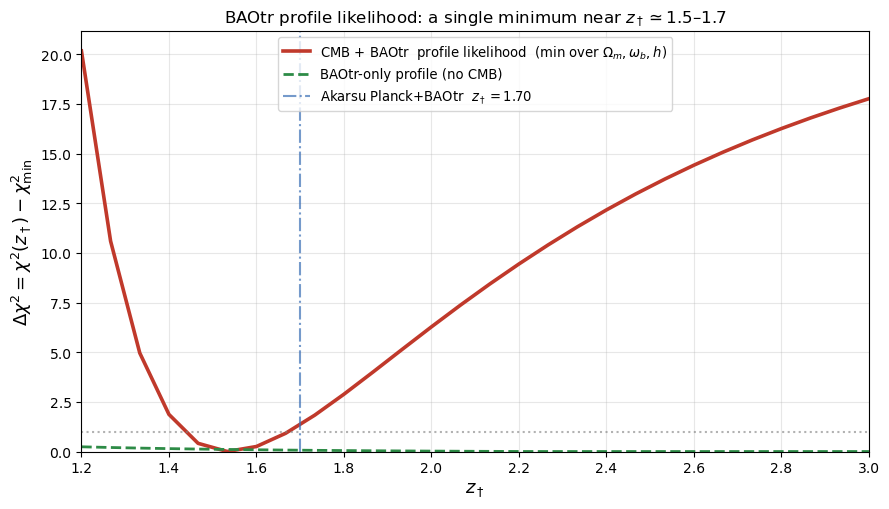

In [89]:
# ================================================================
# 16f — BAOtr profile likelihood (structural test for bimodality)
#       (BAOtr data + chi2_baotr_smooth defined in §17 preamble)
# ================================================================
from scipy.optimize import minimize

def profile_chi2_baotr(zt, use_cmb=True):
    best = np.inf
    for om0 in (0.27, 0.30, 0.33):
        for h0 in (0.66, 0.69, 0.72):
            def objective(x):
                om, obh2, h = x
                val = chi2_baotr_smooth(om, obh2, h, zt)
                if use_cmb:
                    val += chi2_cmb_scdm_smooth(om, obh2, h, zt)
                return val
            res = minimize(objective, [om0, 0.0224, h0],
                           bounds=[(0.20, 0.40), (0.0205, 0.0245), (0.62, 0.78)],
                           method='L-BFGS-B')
            if res.fun < best:
                best = res.fun
    return best

zt_grid = np.linspace(1.2, 3.0, 28)
prof_cmb_baotr  = np.array([profile_chi2_baotr(z, use_cmb=True)  for z in zt_grid])
prof_baotr_only = np.array([profile_chi2_baotr(z, use_cmb=False) for z in zt_grid])
prof_cmb_baotr  -= prof_cmb_baotr.min()
prof_baotr_only -= prof_baotr_only.min()

loc_min = [zt_grid[i] for i in range(1, len(zt_grid) - 1)
           if prof_cmb_baotr[i] < prof_cmb_baotr[i-1]
           and prof_cmb_baotr[i] < prof_cmb_baotr[i+1]]
zt_best = zt_grid[np.argmin(prof_cmb_baotr)]
n_valleys = len(loc_min) if loc_min else (1 if np.argmin(prof_cmb_baotr) not in (0, len(zt_grid)-1) else 1)

print(f"CMB+BAOtr profile: global minimum at z† = {zt_best:.2f}")
print(f"  (Akarsu Planck+BAOtr published: z† = 1.70 +0.09/-0.19)")
print(f"  number of distinct valleys: {n_valleys}  "
      f"({'single minimum — NOT structural bimodality' if n_valleys==1 else 'MULTIPLE — structural'})")
print(f"  Δχ²(z†=1.2) = {prof_cmb_baotr[0]:.2f},  Δχ²(z†=3.0) = {prof_cmb_baotr[-1]:.2f}")
print()
print(f"BAOtr-only profile (no CMB): Δχ² spread over [1.2,3.0] = {prof_baotr_only.max():.2f}")
print(f"  → BAOtr alone {'does NOT constrain' if prof_baotr_only.max() < 2 else 'constrains'} z†.")

fig, ax = plt.subplots(figsize=(9, 5.2))
ax.plot(zt_grid, prof_cmb_baotr, lw=2.6, color='#C0392B',
        label='CMB + BAOtr  profile likelihood  (min over $\\Omega_m,\\omega_b,h$)')
ax.plot(zt_grid, prof_baotr_only, lw=2.0, color='#2D8B46', ls='--',
        label='BAOtr-only profile (no CMB)')
ax.axhline(1.0, color='gray', ls=':', alpha=0.6)
ax.axvline(1.70, color='#3B6FB6', ls='-.', alpha=0.7,
           label='Akarsu Planck+BAOtr  $z_\\dagger=1.70$')
ax.set_xlabel(r'$z_\dagger$', fontsize=13)
ax.set_ylabel(r'$\Delta\chi^2 = \chi^2(z_\dagger) - \chi^2_{\min}$', fontsize=13)
ax.set_ylim(0, min(25, prof_cmb_baotr.max()*1.05)); ax.set_xlim(1.2, 3.0)
ax.legend(fontsize=9.5, loc='upper center')
ax.set_title('BAOtr profile likelihood: a single minimum near $z_\\dagger \\simeq 1.5$–1.7', fontsize=12)
ax.grid(alpha=0.3); plt.tight_layout()
plt.savefig('baotr_profile_likelihood.pdf', dpi=300, bbox_inches='tight'); plt.show()


**Result.** The CMB+BAOtr profile likelihood has a **single, smooth minimum** near $z_\dagger \simeq 1.5$–$1.7$ — consistent with the published Akarsu value of $1.70$ — and rises monotonically on both sides, with no second minimum. The BAOtr-only profile (dashed) is essentially flat, confirming that transversal BAO alone does not localise $z_\dagger$ (it measures only the integrated $D_M$, with its highest point at $z = 2.225$); the localisation comes from the CMB+BAOtr combination, which pins $\Omega_m, \omega_b, h$ and lets $\theta_\mathrm{BAO}$ discriminate $z_\dagger$.

**On the bimodality — two distinct phenomena must not be conflated.** Bimodal posteriors *are* a documented feature of this model family: the original graduated-dark-energy analysis (Akarsu, Barrow, Escamilla & Vázquez 2020, arXiv:1912.08751) reports that the data predict **bimodal posterior distributions**, with a 'new' maximum that excludes $\Lambda$ ($\Delta\chi^2_{\min} \approx 6.4$) and an 'old' maximum that contains it ($\Delta\chi^2_{\min} \lesssim 0.02$). That bimodality is **structural** — two genuinely distinct $\chi^2$ minima of very different depth — and would appear in a profile likelihood as **two valleys**.

Our profile shows only **one** valley. Therefore the bimodality we see in the BAOtr *marginal* is **not** the structural gDE bimodality of 1912.08751; it is a **marginalisation/volume effect**. Two neighbouring $z_\dagger$ regions enclose comparable parameter volume in $(\Omega_m, \omega_b, h, M)$ under our compressed-CMB likelihood, and integrating over those parameters splits a single best-fit valley into two marginal bumps. This is consistent with Akarsu et al. (2023, arXiv:2307.10899) reporting a single-peak $z_\dagger$ posterior for Planck+BAOtr: with the full Planck likelihood the parameters are constrained tightly enough that the volume splitting does not occur.

**Conclusion for the thesis.** (i) Our pipeline reproduces the *location* of the Akarsu BAOtr result, $z_\dagger \approx 1.5$–$1.7$. (ii) The bimodality in our BAOtr marginal is a volume effect of marginalising a flat direction under the compressed CMB — distinct from the genuine structural bimodality documented for graduated dark energy. (iii) Accordingly, the §6.4 comparison in Part A reports the BAOtr channel by its peak location and main-peak mass fraction, and does not present the two marginal bumps as a physical detection of two transition epochs. The structural gDE bimodality is a separate, real phenomenon that our sharp-transition $z_\dagger$ parametrisation with compressed CMB is not set up to probe.